# Exploratory Data Analysis (EDA) of Facial Attributes

This notebook performs Exploratory Data Analysis on the provided image dataset, focusing on the attributes detailed in `list_attribute.txt`. Specifically, it analyzes the distribution of the attributes and details the amount of "Male" image data.

## Objectives
1. Read the provided dataset attributes file (`list_attribute.txt`)
2. Filter the attribute list ensuring it aligns with the actual images that exist in the directory `Images/`.
3. Visualize the overall distribution of various characteristics.
4. Dive deep into the specific characteristic `Male` to find how many males versus females (non-males) are in our processed dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

## 1. Load Attribute Data and List of Real Images

In [2]:
data_path='./images'

df = os.listdir(data_path)
df

['000051.jpg',
 '000052.jpg',
 '000065.jpg',
 '000166.jpg',
 '000198.jpg',
 '000201.jpg',
 '000240.jpg',
 '000282.jpg',
 '000352.jpg',
 '000409.jpg',
 '000414.jpg',
 '000439.jpg',
 '000444.jpg',
 '000474.jpg',
 '000525.jpg',
 '000545.jpg',
 '000559.jpg',
 '000572.jpg',
 '000608.jpg',
 '000653.jpg',
 '000716.jpg',
 '000771.jpg',
 '000798.jpg',
 '000810.jpg',
 '000845.jpg',
 '000858.jpg',
 '000873.jpg',
 '000922.jpg',
 '000989.jpg',
 '001140.jpg',
 '001161.jpg',
 '001218.jpg',
 '001242.jpg',
 '001248.jpg',
 '001256.jpg',
 '001270.jpg',
 '001295.jpg',
 '001401.jpg',
 '001509.jpg',
 '001519.jpg',
 '001613.jpg',
 '001637.jpg',
 '001665.jpg',
 '001708.jpg',
 '001782.jpg',
 '001800.jpg',
 '001894.jpg',
 '001921.jpg',
 '001983.jpg',
 '002085.jpg',
 '002125.jpg',
 '002134.jpg',
 '002150.jpg',
 '002197.jpg',
 '002202.jpg',
 '002223.jpg',
 '002256.jpg',
 '002310.jpg',
 '002362.jpg',
 '002389.jpg',
 '002415.jpg',
 '002427.jpg',
 '002443.jpg',
 '002450.jpg',
 '002456.jpg',
 '002502.jpg',
 '002525.j

In [3]:
# Initialize Paths
attr_path = "list_attribute.txt"
img_dir = "Images/"

# Reading list of valid images from directory
valid_images = set(os.listdir(img_dir))
print(f"Total actual images in directory: {len(valid_images)}")

# The list_attribute.txt starts with the total number of images on the first line, 
# then columns names, and then space-separated values.
# To parse, we can skip the first line.
with open(attr_path, 'r') as f:
    lines = f.readlines()
    
# First line has numbers, second is headers
headers = lines[1].strip().split()
print("Total Headers:", len(headers))


Total actual images in directory: 5017
Total Headers: 40


In [4]:
# Read into dataframe
df_attr = pd.read_csv(attr_path, delim_whitespace=True, skiprows=1, index_col=0)

# Replace the -1 with 0 for easier understanding and manipulation: 1=Yes, 0=No
df_attr = df_attr.replace(-1, 0)
df_attr.head()


C:\Users\naufa\AppData\Local\Temp\ipykernel_128960\1284432748.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_attr = pd.read_csv(attr_path, delim_whitespace=True, skiprows=1, index_col=0)


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [5]:
# Separate valid (exists in Images/) vs invalid (only in list_attribute.txt)
df_valid = df_attr[df_attr.index.isin(valid_images)].copy()
df_invalid = df_attr[~df_attr.index.isin(valid_images)].copy()

print(f"Total entries in list_attribute.txt: {len(df_attr)}")
print(f"Valid (exists in Images/): {len(df_valid)}")
print(f"Invalid (only in list_attribute.txt): {len(df_invalid)}")

print("\n--- Valid DataFrame (head) ---")
display(df_valid.head())

print("\n--- Invalid DataFrame (head) ---")
display(df_invalid.head())

Total entries in list_attribute.txt: 202599
Valid (exists in Images/): 5000
Invalid (only in list_attribute.txt): 197599

--- Valid DataFrame (head) ---


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000051.jpg,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
000052.jpg,0,0,0,1,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
000065.jpg,0,0,0,0,0,0,0,0,1,0,...,0,1,1,0,0,0,0,0,0,1
000166.jpg,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
000198.jpg,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1



--- Invalid DataFrame (head) ---


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


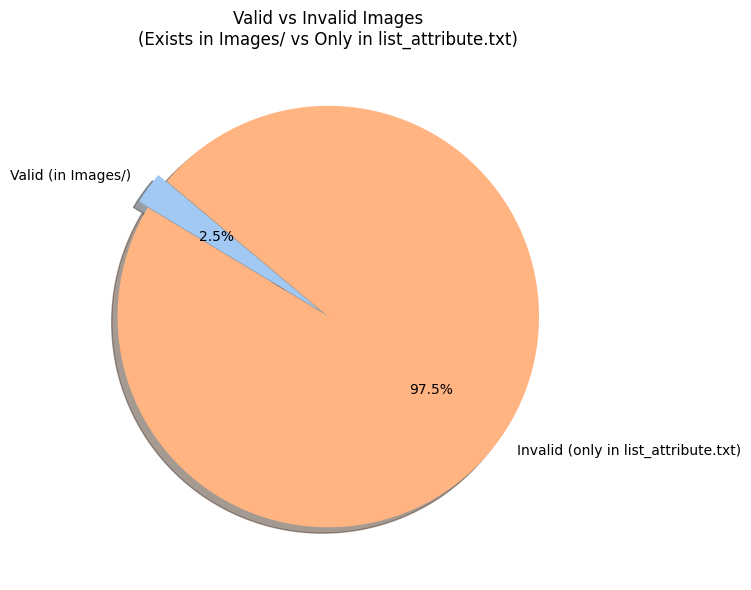

In [6]:
# Pie chart: Valid vs Invalid
labels = ['Valid (in Images/)', 'Invalid (only in list_attribute.txt)']
sizes = [len(df_valid), len(df_invalid)]
colors = sns.color_palette('pastel')[:2]
explode = (0.05, 0)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Valid vs Invalid Images\n(Exists in Images/ vs Only in list_attribute.txt)')
plt.tight_layout()
plt.show()

## 2. Filtering Existing Images

A lot of the images in the dataset metadata may not exist in our actual specific subset/folder `Images/`. We are filtering to the `5017` images shown locally.


In [7]:
# The index name corresponds to the filename (e.g., '000001.jpg')
df_avail = df_attr[df_attr.index.isin(valid_images)].copy()

print(f"Filtered Shape of DataFrame: {df_avail.shape}")
df_avail.head()


Filtered Shape of DataFrame: (5000, 40)


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000051.jpg,1,0,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
000052.jpg,0,0,0,1,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
000065.jpg,0,0,0,0,0,0,0,0,1,0,...,0,1,1,0,0,0,0,0,0,1
000166.jpg,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
000198.jpg,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


## 3. General Attribute Distribution

C:\Users\naufa\AppData\Local\Temp\ipykernel_128960\2114661199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attributes_dist.values, y=attributes_dist.index, palette="viridis")


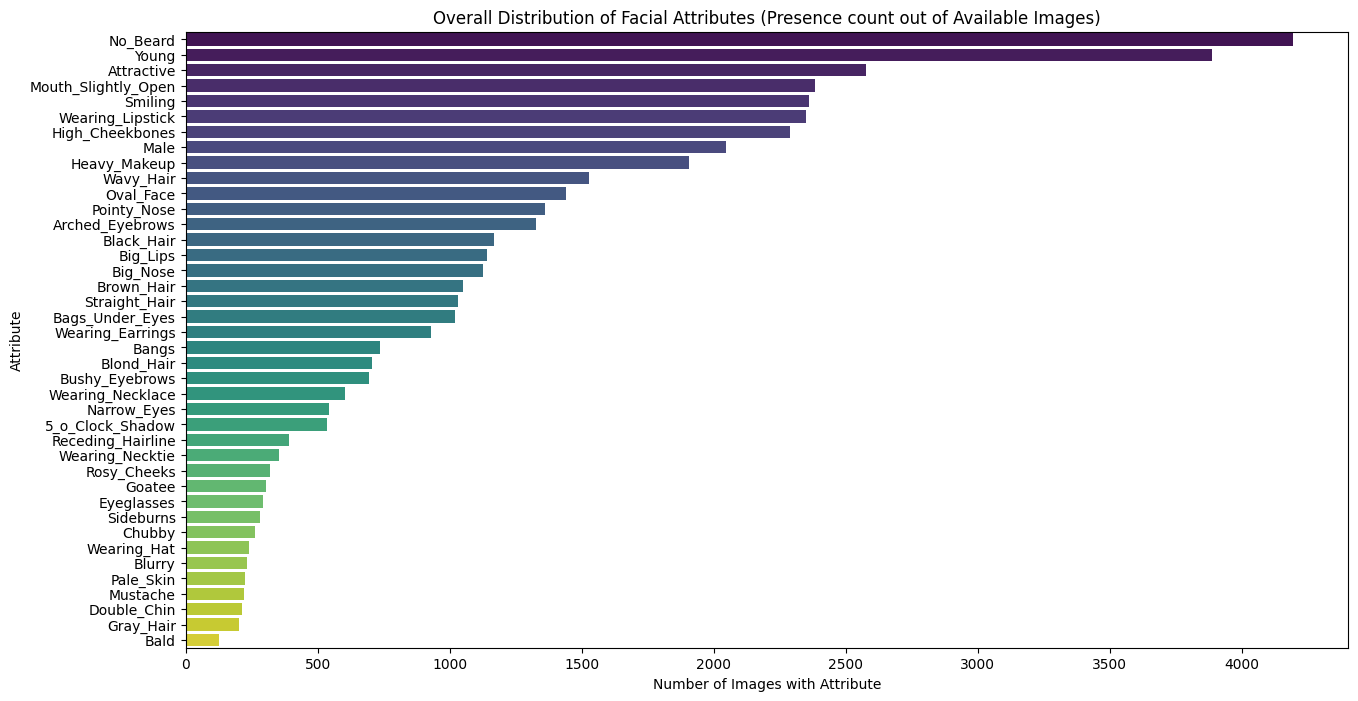

In [8]:
# Calculate counts of attributes
attributes_dist = df_avail.sum().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=attributes_dist.values, y=attributes_dist.index, palette="viridis")
plt.title('Overall Distribution of Facial Attributes (Presence count out of Available Images)')
plt.xlabel('Number of Images with Attribute')
plt.ylabel('Attribute')
plt.show()


## 4. Deep Dive: "Male" Dimension

The `Male` attribute indicates if the subject is recognized as male (1) or non-male/female (0). Let's plot this proportion!


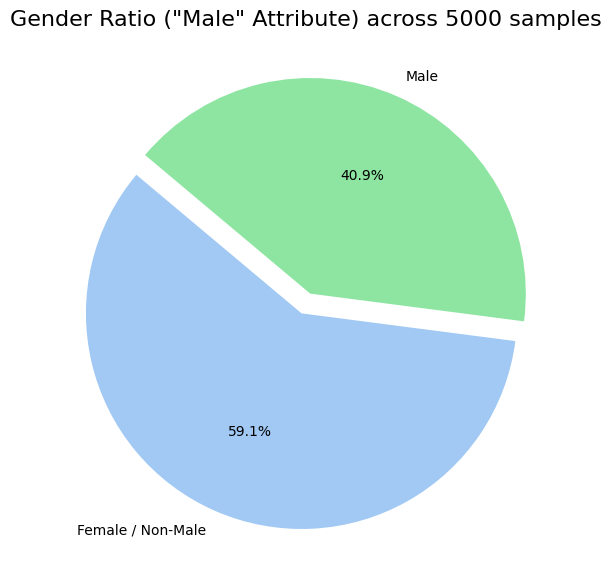

====== MALE ATTRIBUTE BREAKDOWN ======
Total Male Data Count: 2047
Total Non-Male Data Count: 2953
Total Valid Dataset:   5000


In [9]:
male_counts = df_avail['Male'].value_counts()
male_counts.index = ['Female / Non-Male', 'Male']  # 0->Non-Male, 1->Male

# Define a cool color palette for binary breakdown
colors = sns.color_palette("pastel")

# Pie chart distribution
plt.figure(figsize=(7, 7))
plt.pie(male_counts, labels=male_counts.index, autopct='%1.1f%%', startangle=140, colors=[colors[0], colors[2]], explode=[0.05, 0.05])
plt.title(f'Gender Ratio ("Male" Attribute) across {len(df_avail)} samples', fontsize=16)
plt.show()

# Show explicit counts
print("====== MALE ATTRIBUTE BREAKDOWN ======")
print(f"Total Male Data Count: {male_counts['Male']}")
print(f"Total Non-Male Data Count: {male_counts['Female / Non-Male']}")
print(f"Total Valid Dataset:   {len(df_avail)}")
print("======================================")


## 5. Pre-Processing: Split Dataset for GoogLeNet Training

We split the valid dataset (`df_valid`) into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets.
Images are loaded and resized to **224×224** (GoogLeNet input size), and pixel values are normalized to `[0, 1]`.

In [ ]:
from sklearn.model_selection import train_test_split
from PIL import Image

# Use df_valid (images that exist in Images/ directory)
IMG_SIZE = (224, 224)  # GoogLeNet input size
img_dir = 'Images/'

# Prepare file paths and labels (using 'Male' as target attribute)
X_filenames = df_valid.index.tolist()
y_labels = df_valid['Male'].values  # 1 = Male, 0 = Female/Non-Male

print(f"Total valid samples: {len(X_filenames)}")
print(f"Target attribute: 'Male'")
print(f"Label distribution: Male={sum(y_labels)}, Non-Male={len(y_labels)-sum(y_labels)}")

# Split: 70% Train, 15% Validation, 15% Test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filenames, y_labels, test_size=0.30, random_state=42, stratify=y_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n--- Dataset Split ---")
print(f"Train set:      {len(X_train)} samples ({len(X_train)/len(X_filenames)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(X_filenames)*100:.1f}%)")
print(f"Test set:       {len(X_test)} samples ({len(X_test)/len(X_filenames)*100:.1f}%)")

# Function to load and preprocess images
def load_and_preprocess(filenames, img_dir, img_size): #TODO: Use transforms 
    images = []
    for fname in filenames:
        img_path = os.path.join(img_dir, fname)
        img = Image.open(img_path).convert('RGB')
        img = img.resize(img_size)
        img_array = np.array(img) / 255.0  # Normalize to [0, 1]
        images.append(img_array)
    return np.array(images)

# Load images for each split
print("\nLoading and preprocessing images...")
X_train_img = load_and_preprocess(X_train, img_dir, IMG_SIZE)
X_val_img = load_and_preprocess(X_val, img_dir, IMG_SIZE)
X_test_img = load_and_preprocess(X_test, img_dir, IMG_SIZE)

print(f"\n--- Final Shapes ---")
print(f"X_train: {X_train_img.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val_img.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test_img.shape},  y_test:  {y_test.shape}")
print(f"\nPixel value range: [{X_train_img.min():.2f}, {X_train_img.max():.2f}]")
print(f"Image dtype: {X_train_img.dtype}")

Total valid samples: 5000
Target attribute: 'Male'
Label distribution: Male=2047, Non-Male=2953

--- Dataset Split ---
Train set:      3500 samples (70.0%)
Validation set: 750 samples (15.0%)
Test set:       750 samples (15.0%)

Loading and preprocessing images...

--- Final Shapes ---
X_train: (3500, 224, 224, 3), y_train: (3500,)
X_val:   (750, 224, 224, 3),   y_val:   (750,)
X_test:  (750, 224, 224, 3),  y_test:  (750,)

Pixel value range: [0.00, 1.00]
Image dtype: float64


## 7. Visualisasi Hasil Split Dataset

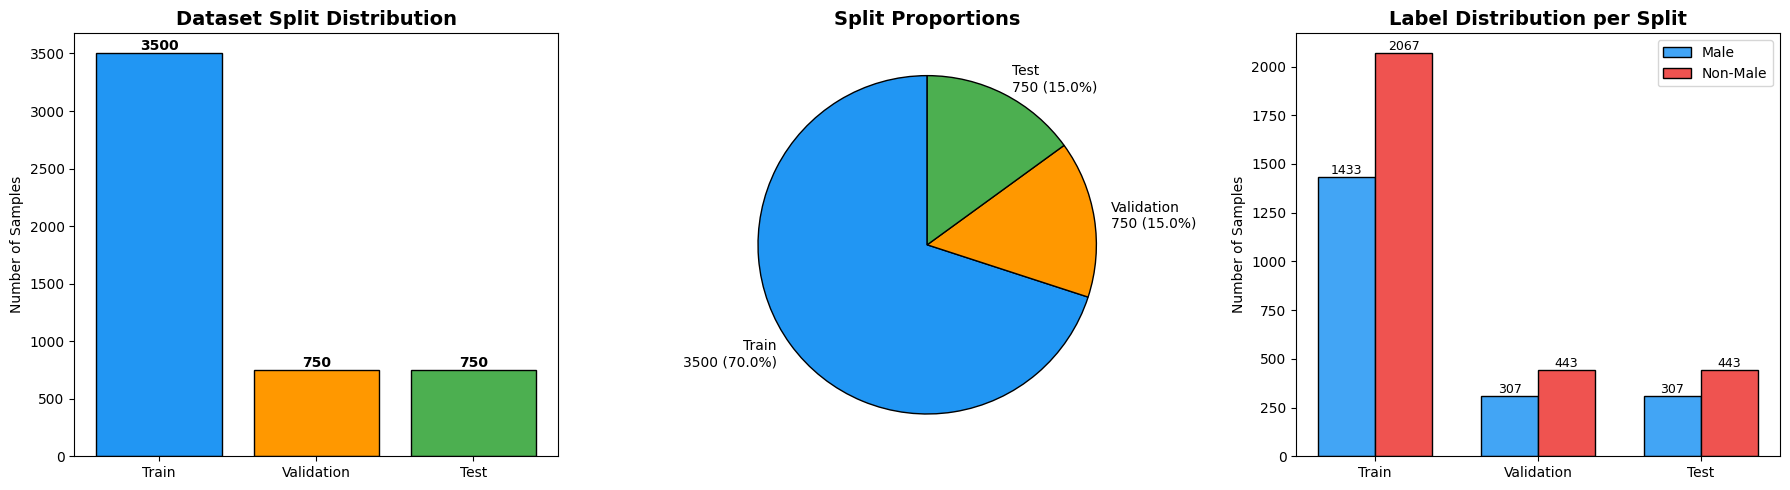

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Split counts
split_names = ['Train', 'Validation', 'Test']
split_counts = [len(X_train), len(X_val), len(X_test)]
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart - Split sizes
bars = axes[0].bar(split_names, split_counts, color=colors, edgecolor='black')
for bar, count in zip(bars, split_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{count}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')

# 2. Pie chart - Split proportions
total = sum(split_counts)
percentages = [f'{name}\n{c} ({c/total*100:.1f}%)' for name, c in zip(split_names, split_counts)]
axes[1].pie(split_counts, labels=percentages, colors=colors, autopct='',
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Split Proportions', fontsize=14, fontweight='bold')

# 3. Stacked bar - Label distribution per split
train_male = sum(y_train)
train_nonmale = len(y_train) - train_male
val_male = sum(y_val)
val_nonmale = len(y_val) - val_male
test_male = sum(y_test)
test_nonmale = len(y_test) - test_male

male_counts = [train_male, val_male, test_male]
nonmale_counts = [train_nonmale, val_nonmale, test_nonmale]
x = np.arange(len(split_names))
width = 0.35

bars1 = axes[2].bar(x - width/2, male_counts, width, label='Male', color='#42A5F5', edgecolor='black')
bars2 = axes[2].bar(x + width/2, nonmale_counts, width, label='Non-Male', color='#EF5350', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(split_names)
axes[2].set_title('Label Distribution per Split', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Number of Samples')
axes[2].legend()

for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Training GoogLeNet Model (PyTorch)

We use a **pretrained GoogLeNet** with PyTorch DataLoader for efficient batching.
- **Loss**: BCEWithLogitsLoss (combines Sigmoid + BCE for numerical stability)
- **Optimizer**: Adam
- **Epochs**: 10, **Batch size**: 32

Train batches: 110, Val batches: 24, Test batches: 24
Using device: cuda

Starting training: 10 epochs, batch_size=32, lr=0.0001
Epoch [1/10] | Train Loss: 0.2198, Acc: 0.9177 | Val Loss: 0.1549, Acc: 0.9320 | Time: 12.2s
Epoch [2/10] | Train Loss: 0.0646, Acc: 0.9786 | Val Loss: 0.1341, Acc: 0.9560 | Time: 11.6s
Epoch [3/10] | Train Loss: 0.0207, Acc: 0.9957 | Val Loss: 0.1421, Acc: 0.9507 | Time: 11.9s
Epoch [4/10] | Train Loss: 0.0166, Acc: 0.9957 | Val Loss: 0.1580, Acc: 0.9440 | Time: 12.1s
Epoch [5/10] | Train Loss: 0.0091, Acc: 0.9986 | Val Loss: 0.2808, Acc: 0.9253 | Time: 11.9s
Epoch [6/10] | Train Loss: 0.0134, Acc: 0.9960 | Val Loss: 0.1666, Acc: 0.9547 | Time: 11.8s
Epoch [7/10] | Train Loss: 0.0109, Acc: 0.9974 | Val Loss: 0.1389, Acc: 0.9680 | Time: 12.1s
Epoch [8/10] | Train Loss: 0.0042, Acc: 0.9997 | Val Loss: 0.1420, Acc: 0.9600 | Time: 12.5s
Epoch [9/10] | Train Loss: 0.0066, Acc: 0.9986 | Val Loss: 0.1540, Acc: 0.9627 | Time: 12.3s
Epoch [10/10] | Train Loss: 0.0027

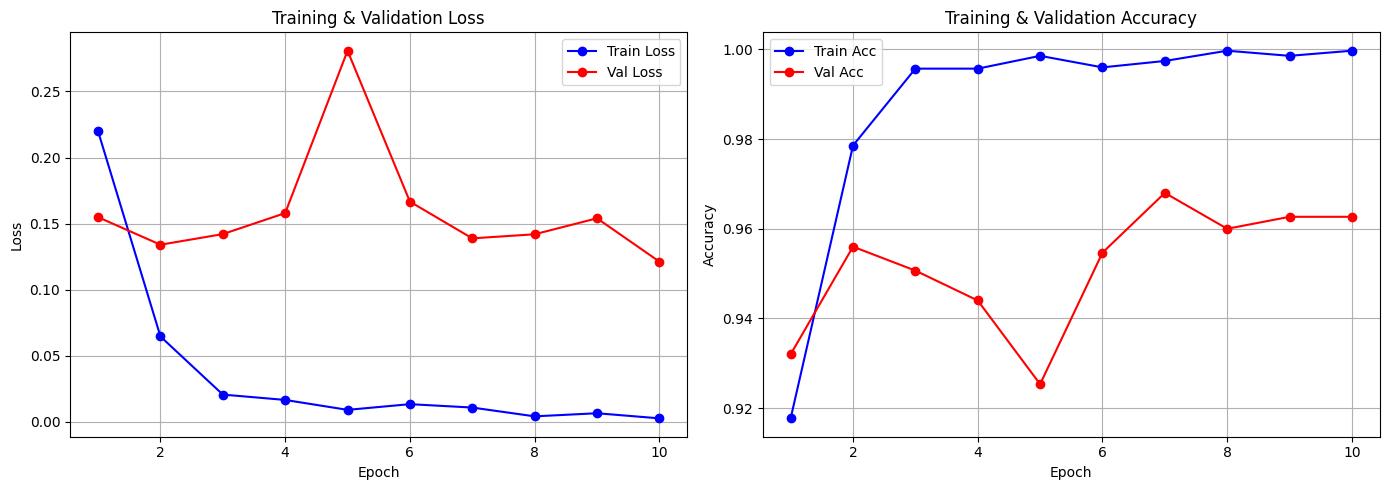

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import time

# --- Custom Dataset ---
class FaceDataset(Dataset):
    def __init__(self, images, labels):
        # images: numpy (N, 224, 224, 3) float32 [0,1] -> torch (N, 3, 224, 224)
        self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# --- DataLoaders ---
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

train_dataset = FaceDataset(X_train_img, y_train)
val_dataset = FaceDataset(X_val_img, y_val)
test_dataset = FaceDataset(X_test_img, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# --- Pretrained GoogLeNet ---
model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 1)  # Binary output (single logit)
model = model.to(device)

# --- Loss & Optimizer ---
criterion = nn.BCEWithLogitsLoss()  # Sigmoid + BCE combined
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Training Loop ---
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f'\nStarting training: {EPOCHS} epochs, batch_size={BATCH_SIZE}, lr={LEARNING_RATE}')
print('='*70)

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # Training phase
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        if isinstance(outputs, models.GoogLeNetOutputs):
            outputs = outputs.logits
        outputs = outputs.squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validation phase
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    val_loss = running_loss / total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    elapsed = time.time() - start_time
    print(f'Epoch [{epoch+1}/{EPOCHS}] | '
          f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | '
          f'Time: {elapsed:.1f}s')

print('='*70)
print('Training complete!')

# --- Plot Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Train Loss')
ax1.plot(range(1, EPOCHS+1), val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), train_accs, 'b-o', label='Train Acc')
ax2.plot(range(1, EPOCHS+1), val_accs, 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy'); ax2.legend(); ax2.grid(True)
#TODO: TAMBAHIN TIME NYA JUGA EPOCH 1-10 TOTAL TIMENYA
plt.tight_layout()
plt.show()

## 7. Model Evaluation

Evaluate the trained GoogLeNet model on the **test set** using:
- **Confusion Matrix**: visualizes true vs predicted labels
- **Classification Report**: precision, recall, F1-score per class

Test Accuracy: 0.9747 (731/750)


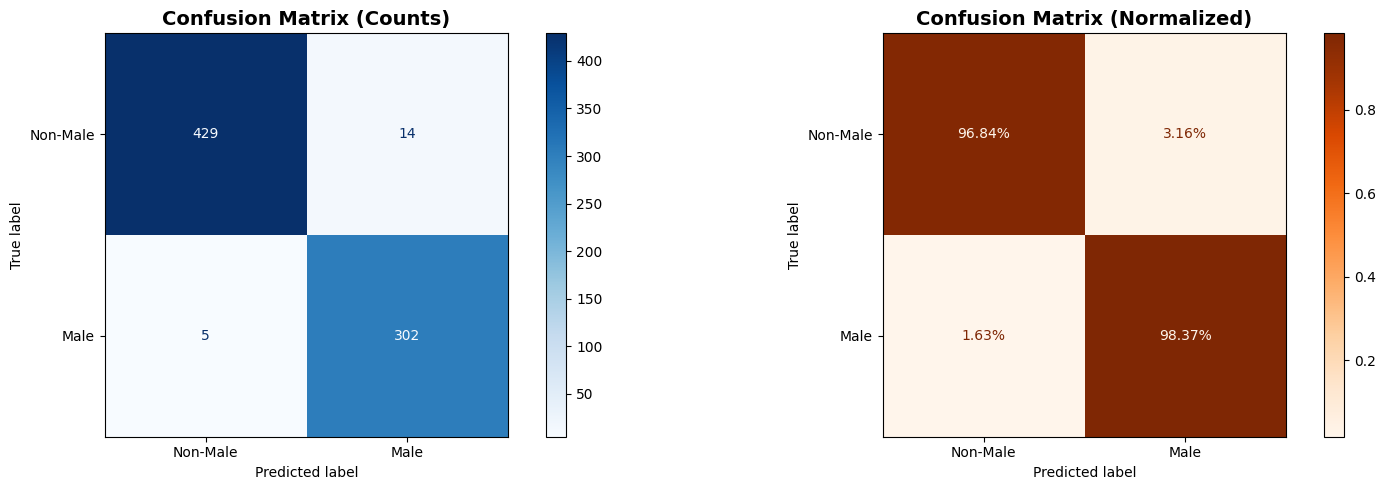


Classification Report
              precision    recall  f1-score   support

Non-Male (0)       0.99      0.97      0.98       443
    Male (1)       0.96      0.98      0.97       307

    accuracy                           0.97       750
   macro avg       0.97      0.98      0.97       750
weighted avg       0.98      0.97      0.97       750



In [13]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# --- Predict on Test Set ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        preds = (torch.sigmoid(outputs) >= 0.5).float().cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f} ({int(test_acc * len(all_labels))}/{len(all_labels)})')

# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute values
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Male', 'Male'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Non-Male', 'Male'])
disp2.plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# --- Classification Report ---
print('\n' + '='*60)
print('Classification Report')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=['Non-Male (0)', 'Male (1)']))

In [14]:
#TODO: SAVE MODEL
torch.save(model.state_dict(), 'best_model.pth')